# PBMF vs. Langevin: non-Gaussianity comparison

Compares the PBMF theory against the Langevin simulation data, using the files produced by:
- `preprocess_PBMF_distributions.py` (PBMF side, in `processing_data/PBMF/`)
- `aggregate_equilibrium_pdfs.py` + `preprocess_Langevin_distributions.py` (Langevin side, in `processing_data/Langevin/`)

This notebook is self-contained: it does not import from `plot_PBMF_gaussianity.ipynb` or from either preprocessing script (some small helpers are copied where needed, so the two notebooks/scripts stay independent).

Two sections:
1. **Average distributions** -- PBMF theory vs. Langevin simulation, as a frequency histogram and as a count histogram.
2. **Individual species distributions** -- the same two histograms, for the species PBMF flagged as most non-Gaussian (see `--pbmf-dir` in `preprocess_Langevin_distributions.py`).

Both sides are already frequency histograms (per-bin probability mass) on their own equally spaced, native grid, with no density involved: PBMF's via `preprocess_PBMF_distributions.py`'s `--S`-truncated `_favg_S<S>.txt`/`_ftop_S<S>.txt` files, the simulation's via `aggregate_equilibrium_pdfs.py`'s `--nmin`/`--nmax`/`--dn` histogram. Their native bin *width* already matches (both built with the same `dn`), but their native bin *count* generally doesn't (PBMF's grid starts near 0 and is only as long as the solver needed; the simulation's spans a fixed `--nmin`/`--nmax`). A per-bin frequency is only comparable between histograms of equal bin width -- not equal bin count -- so every `plot_*` function below takes `dn` (the physically meaningful, user-facing knob) rather than a bin count: both sides are merged by the *same* integer number of native bins at once (see `rebin_histogram_pair`), that number chosen, among the common divisors of both sides' native bin counts, to give a merged bin width as close as possible to the requested `dn`. This keeps a native bin's value from ever being split on either side, and keeps the two merged histograms at a matching (though not necessarily requested-`dn`-exact) bin width; if the two native bin widths themselves aren't equal, no common choice can fix that, and `rebin_histogram_pair` prints a warning and skips that pair rather than plotting a mismatched comparison. Frequency is turned into an equivalent count by scaling by `N_SAMPLES` (the number of samples pooled per species in the simulation, a fixed run parameter -- 10000 for the current data, and the same `S` PBMF's frequency histograms were truncated at).

**`sgraph` and `seedinit`.** Each interaction graph realization has its own `sgraph` index (PBMF has always tracked this; the simulation now does too, via `Ecosystem_Dynamics_on_Graphs_in_Temperature.cpp`'s `--graph_id`, embedded in its output filenames as `RRG_sgraph_<n>` and threaded through `aggregate_equilibrium_pdfs.py`/`preprocess_Langevin_distributions.py`). Every `plot_*` function below takes both, with default `sgraph=None`/`seedinit=None`:
- **Section 1** (`plot_avg_*`): `sgraph=None` pools every graph realization on *both* sides (simulation and PBMF), matching the previous, pre-`--graph_id` behavior; `sgraph=<n>` uses only that one realization on both sides. `seedinit` only affects PBMF (the simulation has no notion of it): with a given `sgraph`, `seedinit=None` pools PBMF over every seedinit replicate of that `sgraph`, while `seedinit=<m>` picks one specific replicate; `seedinit` is ignored when `sgraph` is `None`.
- **Section 2** (`plot_species_*`): `sgraph` is **required** (not `None`) -- a species index is tied to one specific interaction graph (different graphs mean different neighbors/interactions for "the same" index), so pooling individual-species curves across `sgraph` isn't physically meaningful. `seedinit` behaves as in section 1 (PBMF-only, optional).

In [113]:
import os
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.2,
})

## Configuration

In [114]:
PBMF_DIR = "/run/media/david/Data/Research/Ecology/Results/PBMF/Several_epsilon"
PBMF_DIST_DIR = os.path.join(PBMF_DIR, "Distributions")

LANGEVIN_DIR = "/run/media/david/Data/Research/Ecology/Langevin/Results/PDF"
LANGEVIN_DIST_DIR = os.path.join(LANGEVIN_DIR, "Distributions")

# Total number of samples pooled per species in the Langevin simulation (N_ext * N_meas in
# Ecosystem_Dynamics_on_Graphs_in_Temperature.cpp's own terms). Turns a frequency into an
# equivalent count (frequency * N_SAMPLES) on both sides -- including PBMF's, whose predicted
# frequency histograms (preprocess_PBMF_distributions.py's --S) are truncated at the same
# sample size so the two stay comparable.
N_SAMPLES = 10000

## Shared helpers

Filename parsing is copied from `preprocess_PBMF_distributions.py` / `preprocess_Langevin_distributions.py` rather than imported, so this notebook has no dependency on either script.

In [ ]:
# --- PBMF filenames (copied from preprocess_PBMF_distributions.py) ---

PBMF_FILENAME_RE = re.compile(
    r"eps_(?P<eps>[0-9.eE+-]+)_mu_(?P<mu>[0-9.eE+-]+)_sigma_(?P<sigma>[0-9.eE+-]+)"
    r"_N_(?P<N>\d+)_c_(?P<c>\d+)_sgraph_(?P<sgraph>\d+)"
    r"_LV_av0_(?P<av0>[0-9.eE+-]+)_stdn0_(?P<stdn0>[0-9.eE+-]+)"
    r"_T_(?P<T>[0-9.eE+-]+)_lda_(?P<lda>[0-9.eE+-]+)_tol_(?P<tol>[0-9.eE+-]+)"
    r"_maxiter_(?P<maxiter>\d+)_damping_(?P<damping>[0-9.eE+-]+)"
    r"_n1_(?P<n1>[0-9.eE+-]+)_dn_(?P<dn>[0-9.eE+-]+)_nmaxlimit_(?P<nmaxlimit>[0-9.eE+-]+)"
    r"_distributions_seedseq_(?P<seedseq>\d+)_seedinit_(?P<seedinit>\d+)\.txt$"
)
PBMF_AVG_DIST_SUFFIX = f"_favg_S{N_SAMPLES}.txt"
PBMF_TOP_NONGAUSSIAN_SUFFIX = f"_ftop_S{N_SAMPLES}.txt"
PBMF_AVG_DIST_COLUMNS = {"n": 0, "freqP_avg": 1, "freqPhat_avg": 2}


def parse_pbmf_filename(name):
    m = PBMF_FILENAME_RE.search(name)
    if m is None:
        return None
    d = {k: float(v) for k, v in m.groupdict().items()}
    for int_key in ("N", "c", "sgraph", "maxiter", "seedseq", "seedinit"):
        d[int_key] = int(d[int_key])
    return d


# --- Langevin filenames (copied from preprocess_Langevin_distributions.py) ---

LANGEVIN_FILENAME_RE = re.compile(
    r"^Lotka-Volterra_epsilon_(?P<epsilon>[^_]+)_(?P<ia_label>.+)_lambda_(?P<lambda_>[^_]+)"
    r"_h_(?P<h>[^_]+)_tmax_(?P<tmax>[^_]+)_deltatsave_(?P<deltatsave>[^_]+)"
    r"_N_(?P<N>\d+)_c_(?P<c>[^_]+)_mu_(?P<mu>[^_]+)_sigma_(?P<sigma>[^_]+)_T_(?P<T>[^_]+)"
    r"_sgraph_(?P<sgraph>\d+)_PDF\.txt$"
)
LANGEVIN_AVG_DIST_SUFFIX = "_avg_dist_fit.txt"
LANGEVIN_PBMF_TOP_NONGAUSSIAN_SUFFIX = "_PBMF_top_nongaussian_species.txt"
LANGEVIN_AVG_DIST_COLUMNS = {
    "n": 0,
    "P_count_avg": 1, "P_count_median": 2, "P_count_std": 3,
    "P_freq_avg": 4, "P_freq_median": 5, "P_freq_std": 6,
    "Phat_freq_avg": 10, "Phat_freq_median": 11, "Phat_freq_std": 12,
}


def parse_langevin_filename(name):
    m = LANGEVIN_FILENAME_RE.match(name)
    if m is None:
        return None
    d = dict(m.groupdict())
    d["lambda"] = d.pop("lambda_")
    for key in ("epsilon", "lambda", "h", "tmax", "deltatsave", "c", "mu", "sigma", "T"):
        d[key] = float(d[key])
    d["N"] = int(d["N"])
    d["sgraph"] = int(d["sgraph"])
    return d


# --- Shared plotting helper ---

def _add_style_legend(ax, loc="lower left", fontsize=11):
    """Add a second, fixed legend clarifying that points are the simulation and lines are
    PBMF theory, independent of the color-coded (eps/sigma/species) legend already on ax.
    Must be called after ax.legend(...) has already been captured into a variable and
    detached via ax.add_artist(...), since a second ax.legend(...) call would otherwise
    silently remove the first one."""
    handles = [
        Line2D([0], [0], color="black", marker="o", linestyle="none", markersize=5, label="Simulation"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="PBMF (theory)"),
    ]
    style_legend = ax.legend(handles=handles, loc=loc, fontsize=fontsize, frameon=False, handlelength=2.5)
    ax.add_artist(style_legend)

In [116]:
def rebin_histogram_pair(centers_a, values_a, centers_b, values_b, dn_user):
    """Merge two equally spaced (native) frequency/count histograms into a common, coarser bin
    width close to dn_user, by summing whole groups of consecutive native bins on each side: no
    native bin's value is ever split. The same group size k is used on both sides -- since a
    per-bin frequency/count is only comparable between histograms of equal bin width, and using
    the same k is what keeps the two merged histograms at a matching width whenever the two
    native widths already match (checked below). k is chosen among the *common* divisors of
    both native bin counts (a k that only divides one side's native bin count would split a
    native bin on the other side), closest to giving a bin width of dn_user; ties round to the
    smaller k (finer/more bins).

    If the two native bin widths are not (approximately) equal, no common k can make the merged
    widths match: a warning is printed and (None, None, None, None, None, None, None) is
    returned so the caller can skip this pair.

    Returns (edges_a, centers_a, values_a, edges_b, centers_b, values_b, dn_new) -- dn_new is
    the actual merged bin width used on both sides, which may differ from dn_user.
    """
    dn_native_a = centers_a[1] - centers_a[0]
    dn_native_b = centers_b[1] - centers_b[0]
    if not np.isclose(dn_native_a, dn_native_b, rtol=1e-3):
        print(f"  [warn] native bin widths differ ({dn_native_a:.6g} vs {dn_native_b:.6g}) -- "
              f"not directly comparable, skipping")
        return None, None, None, None, None, None, None

    n_native_a, n_native_b = len(centers_a), len(centers_b)
    common_divisors = [k for k in range(1, min(n_native_a, n_native_b) + 1)
                        if n_native_a % k == 0 and n_native_b % k == 0]
    k = min(common_divisors, key=lambda k: (abs(k * dn_native_a - dn_user), k))

    def merge(centers, values, k):
        n_bins = len(centers) // k
        new_values = values.reshape(n_bins, k).sum(axis=1)
        new_centers = centers.reshape(n_bins, k).mean(axis=1)
        dn_new = (centers[1] - centers[0]) * k
        new_edges = np.concatenate([new_centers - dn_new / 2, [new_centers[-1] + dn_new / 2]])
        return new_edges, new_centers, new_values

    edges_a, new_centers_a, new_values_a = merge(centers_a, values_a, k)
    edges_b, new_centers_b, new_values_b = merge(centers_b, values_b, k)
    dn_new = k * dn_native_a
    return edges_a, new_centers_a, new_values_a, edges_b, new_centers_b, new_values_b, dn_new

## 1. Average distributions: PBMF theory vs. Langevin simulation

For a given (epsilon, sigma), PBMF's species-averaged distribution is pooled (mean) over every `sgraph`/`seedinit` replicate it was run with; the Langevin side is already a single, pre-pooled `*_avg_dist_fit.txt` file (see `preprocess_Langevin_distributions.py`).

In [ ]:
def find_pbmf_avg_dist_files(pbmf_dist_dir, eps, sigma, sgraph=None, seedinit=None, tol=1e-6):
    """Every PBMF PBMF_AVG_DIST_SUFFIX file matching (eps, sigma) -- and, if sgraph is given,
    one specific graph realization (and, if seedinit is also given, one specific initial
    condition within that graph); otherwise every sgraph/seedinit replicate."""
    pattern = os.path.join(pbmf_dist_dir, f"PBMF_gr_in_RRG_*{PBMF_AVG_DIST_SUFFIX}")
    matches = []
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(PBMF_AVG_DIST_SUFFIX)] + ".txt"
        params = parse_pbmf_filename(reconstructed)
        if params is None:
            continue
        if not (np.isclose(params["eps"], eps, atol=tol) and np.isclose(params["sigma"], sigma, atol=tol)):
            continue
        if sgraph is not None and params["sgraph"] != sgraph:
            continue
        if seedinit is not None and params["seedinit"] != seedinit:
            continue
        matches.append(path)
    return matches


def load_pbmf_pooled_average(pbmf_dist_dir, eps, sigma, column="freqP_avg", sgraph=None, seedinit=None):
    """Pool (mean) the given column of every PBMF PBMF_AVG_DIST_SUFFIX file matching (eps,
    sigma) -- and, if sgraph is given, one specific graph realization (pooling then only over
    its seedinit replicates, unless seedinit is also given, in which case a single file); with
    sgraph=None (seedinit is only meaningful together with a specific sgraph, and is ignored
    otherwise), every sgraph/seedinit replicate is pooled. Replicates share the same grid
    start/step but can have different lengths (the solver only extends the grid as far as it
    needs), so shorter replicates are zero-padded up to the longest grid before averaging.

    Returns (n, pooled_mean, n_replicates); (None, None, 0) if no file is found.
    """
    paths = find_pbmf_avg_dist_files(pbmf_dist_dir, eps, sigma, sgraph=sgraph, seedinit=seedinit)
    if not paths:
        return None, None, 0
    col = PBMF_AVG_DIST_COLUMNS[column]
    curves = [np.loadtxt(path, comments="#")[:, [0, col]] for path in paths]
    n_ref = max((c[:, 0] for c in curves), key=len)
    stacked = np.zeros((len(curves), len(n_ref)))
    for i, c in enumerate(curves):
        stacked[i, :len(c)] = c[:, 1]
    return n_ref, stacked.mean(axis=0), len(paths)


def find_langevin_avg_dist_files(langevin_dist_dir, eps, sigma, sgraph=None, tol=1e-6):
    """Every Langevin LANGEVIN_AVG_DIST_SUFFIX file matching (eps, sigma) -- and, if sgraph is
    given, one specific graph realization; otherwise every sgraph aggregate_equilibrium_pdfs.py
    was run for (one file each, since different sgraph are never pooled together upstream)."""
    pattern = os.path.join(langevin_dist_dir, f"Lotka-Volterra_*{LANGEVIN_AVG_DIST_SUFFIX}")
    matches = []
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(LANGEVIN_AVG_DIST_SUFFIX)] + ".txt"
        params = parse_langevin_filename(reconstructed)
        if params is None:
            continue
        if not (np.isclose(params["epsilon"], eps, atol=tol) and np.isclose(params["sigma"], sigma, atol=tol)):
            continue
        if sgraph is not None and params["sgraph"] != sgraph:
            continue
        matches.append(path)
    return matches


def load_langevin_pooled_average(langevin_dist_dir, eps, sigma, column, sgraph=None, tol=1e-6):
    """Pool (mean) the given column of every Langevin LANGEVIN_AVG_DIST_SUFFIX file matching
    (eps, sigma) -- and, if sgraph is given, one specific graph realization (a single file);
    otherwise every sgraph aggregate_equilibrium_pdfs.py was run for, as an *unweighted* mean
    across sgraph (each graph realization counts equally regardless of its own sample count --
    the same convention used for PBMF's own sgraph/seedinit pooling above). Every file normally
    shares the same grid (built from one shared --nmin/--nmax/--dn per aggregate_equilibrium_pdfs.py
    run), but replicates are still zero-padded up to the longest grid before averaging, for
    robustness, exactly as load_pbmf_pooled_average does.

    Returns (n, pooled_mean, n_sgraph); (None, None, 0) if no file is found.
    """
    paths = find_langevin_avg_dist_files(langevin_dist_dir, eps, sigma, sgraph=sgraph)
    if not paths:
        return None, None, 0
    col = LANGEVIN_AVG_DIST_COLUMNS[column]
    curves = [np.loadtxt(path, skiprows=1)[:, [0, col]] for path in paths]
    n_ref = max((c[:, 0] for c in curves), key=len)
    stacked = np.zeros((len(curves), len(n_ref)))
    for i, c in enumerate(curves):
        stacked[i, :len(c)] = c[:, 1]
    return n_ref, stacked.mean(axis=0), len(paths)


def list_available_eps(langevin_dist_dir, sigma, sgraph=None, tol=1e-6):
    """Every epsilon value that has a Langevin avg_dist_fit file for this sigma (and, if sgraph
    is given, this graph realization) -- the default eps_values used by plot_avg_*_histogram_vs_eps
    when none are given explicitly."""
    pattern = os.path.join(langevin_dist_dir, f"Lotka-Volterra_*{LANGEVIN_AVG_DIST_SUFFIX}")
    values = set()
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(LANGEVIN_AVG_DIST_SUFFIX)] + ".txt"
        params = parse_langevin_filename(reconstructed)
        if params is None or not np.isclose(params["sigma"], sigma, atol=tol):
            continue
        if sgraph is not None and params["sgraph"] != sgraph:
            continue
        values.add(params["epsilon"])
    return sorted(values)


def list_available_sigma(langevin_dist_dir, eps, sgraph=None, tol=1e-6):
    """Every sigma value that has a Langevin avg_dist_fit file for this epsilon (and, if sgraph
    is given, this graph realization) -- the default sigma_values used by
    plot_avg_*_histogram_vs_sigma when none are given explicitly."""
    pattern = os.path.join(langevin_dist_dir, f"Lotka-Volterra_*{LANGEVIN_AVG_DIST_SUFFIX}")
    values = set()
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(LANGEVIN_AVG_DIST_SUFFIX)] + ".txt"
        params = parse_langevin_filename(reconstructed)
        if params is None or not np.isclose(params["epsilon"], eps, atol=tol):
            continue
        if sgraph is not None and params["sgraph"] != sgraph:
            continue
        values.add(params["sigma"])
    return sorted(values)

In [ ]:
def _plot_avg_multi(dn, kind, eps=None, sigma=None, values=None, sgraph=None, seedinit=None, use_phat=False,
                     pbmf_dist_dir=PBMF_DIST_DIR, langevin_dist_dir=LANGEVIN_DIST_DIR,
                     n_samples=N_SAMPLES, figsize=(8, 6), dpi=150, legend_loc='best', legend_fontsize=14,
                     title_fontsize=18, label_fontsize=20, tick_fontsize=14, linewidth=2, markersize=4,
                     logscalex=False, logscaley=False, ax=None, save_to=None,
                     xmin=None, xmax=None, ymin=None, ymax=None, title=None):
    """Overlay several (epsilon, sigma) curve-pairs (simulation as small points at bin
    centers + PBMF theory as a solid line, one color per value) in one plot. Exactly one of
    eps/sigma must be given (the fixed one); the other varies over `values` (every value found
    in the Langevin data, if not given).

    sgraph selects which interaction graph realization(s) to use, on both sides:
      - sgraph=None (default): pool every sgraph available -- simulation as an unweighted mean
        across its per-sgraph files (see load_langevin_pooled_average), PBMF as an unweighted
        mean across every sgraph/seedinit replicate it was run with (see load_pbmf_pooled_average).
      - sgraph=<n>: use only that one graph realization on both sides.
    seedinit only affects PBMF (the simulation has no notion of seedinit): with sgraph given,
    seedinit=None pools PBMF over every seedinit replicate for that sgraph, while seedinit=<m>
    picks that one specific replicate; seedinit is ignored when sgraph is None.

    Simulation and PBMF are each already a frequency histogram on their own native grid, at a
    matching native bin width, so they're rebinned together (see rebin_histogram_pair) onto a
    common bin width close to dn -- dn (not a bin count) is the physically meaningful quantity
    to request, since the actual bin count generally differs between the two sides (their
    native ranges differ). The actual bin width used may differ slightly from dn, since it must
    be an integer multiple of the shared native bin width.
    """
    if kind not in ("frequency", "count"):
        raise ValueError("kind must be 'frequency' or 'count'")
    if (eps is None) == (sigma is None):
        raise ValueError("Specify exactly one of eps (fixed) or sigma (fixed); the other varies over `values`.")
    vary_eps = eps is None

    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })

    if values is None:
        values = (list_available_eps(langevin_dist_dir, sigma, sgraph=sgraph) if vary_eps
                  else list_available_sigma(langevin_dist_dir, eps, sgraph=sgraph))
    if not values:
        print("  [warn] no matching Langevin avg_dist_fit files found")
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.subplots_adjust(left=0.17, bottom=0.14, right=0.98, top=0.90)
    else:
        fig = ax.figure
    color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(values), 1)))

    # dn_seen = set()
    for idx, val in enumerate(values):
        this_eps = val if vary_eps else eps
        this_sigma = sigma if vary_eps else val
        color = color_cycle[idx % len(color_cycle)]

        native_centers, native_freq, n_langevin = load_langevin_pooled_average(
            langevin_dist_dir, this_eps, this_sigma,
            column="Phat_freq_avg" if use_phat else "P_freq_avg", sgraph=sgraph,
        )
        if native_centers is None:
            print(f"  [warn] no Langevin avg_dist_fit file for eps={this_eps}, sigma={this_sigma}"
                  + (f", sgraph={sgraph}" if sgraph is not None else ""))
            continue
        native_sim = native_freq if kind == "frequency" else native_freq * n_samples

        pbmf_n, pbmf_native_freq, n_replicates = load_pbmf_pooled_average(
            pbmf_dist_dir, this_eps, this_sigma, column="freqPhat_avg" if use_phat else "freqP_avg",
            sgraph=sgraph, seedinit=seedinit,
        )
        if pbmf_n is None:
            print(f"  [warn] no PBMF avg_dist_fit files for eps={this_eps}, sigma={this_sigma}")
            continue
        pbmf_native = pbmf_native_freq if kind == "frequency" else pbmf_native_freq * n_samples

        new_edges, new_centers, sim_vals, pbmf_edges, pbmf_centers, pbmf_vals, dn_new = rebin_histogram_pair(
            native_centers, native_sim, pbmf_n, pbmf_native, dn
        )
        if dn_new is None:
            continue
        # dn_seen.add(np.round(dn_new, 3))

        label = fr"$\epsilon={val:.2f}$" if vary_eps else fr"$\sigma={val:.2f}$"
        ax.plot(new_centers, sim_vals, marker="o", linestyle="none", markersize=markersize,
                color=color, label=label)
        ax.step(pbmf_edges, np.append(pbmf_vals, pbmf_vals[-1]), where="post",
                linewidth=linewidth, color=color)

    if logscalex:
        ax.set_xscale("log")
    if logscaley:
        ax.set_yscale("log")
    ax.set_xlabel(r"$n$", fontsize=label_fontsize)
    ylabel = "Frequency" if kind == "frequency" else "Count"
    if use_phat:
        ylabel += r" of $\hat{P}(n)$"
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    fixed_label = fr"$\sigma={sigma:.2f}$" if vary_eps else fr"$\epsilon={eps:.2f}$"
    sgraph_label = f", sgraph={sgraph}" if sgraph is not None else ""
    seedinit_label = f", seedinit={seedinit}" if (sgraph is not None and seedinit is not None) else ""
    # dn_label = f"dn={dn_seen.pop():.4g}" if len(dn_seen) == 1 else f"dn={sorted(dn_seen)}"
    # ttl = title if title is not None else f"{fixed_label}{sgraph_label} ({dn_label})"
    ttl = title if title is not None else f"{fixed_label}{sgraph_label}{seedinit_label}"
    ax.set_title(ttl, fontsize=title_fontsize)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscalex:
        ax.xaxis.set_major_formatter(LogFormatterMathtext())
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

    main_legend = ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5)
    ax.add_artist(main_legend)
    _add_style_legend(ax)

    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)

    if save_to is not None:
        fig.savefig(save_to)
    plt.show()


def plot_avg_frequency_histogram_vs_eps(sigma, dn, eps_values=None, **kwargs):
    """Frequency histogram, one curve-pair per epsilon, for a fixed sigma (see _plot_avg_multi
    for the sgraph/seedinit pooling semantics)."""
    _plot_avg_multi(dn, kind="frequency", sigma=sigma, values=eps_values, **kwargs)


def plot_avg_count_histogram_vs_eps(sigma, dn, eps_values=None, **kwargs):
    """Like plot_avg_frequency_histogram_vs_eps, but on a count scale (frequency * n_samples
    for both sides -- see the N_SAMPLES configuration cell)."""
    _plot_avg_multi(dn, kind="count", sigma=sigma, values=eps_values, **kwargs)


def plot_avg_frequency_histogram_vs_sigma(eps, dn, sigma_values=None, **kwargs):
    """Frequency histogram, one curve-pair per sigma, for a fixed epsilon (see _plot_avg_multi
    for the sgraph/seedinit pooling semantics)."""
    _plot_avg_multi(dn, kind="frequency", eps=eps, values=sigma_values, **kwargs)


def plot_avg_count_histogram_vs_sigma(eps, dn, sigma_values=None, **kwargs):
    """Like plot_avg_frequency_histogram_vs_sigma, but on a count scale (frequency * n_samples
    for both sides -- see the N_SAMPLES configuration cell)."""
    _plot_avg_multi(dn, kind="count", eps=eps, values=sigma_values, **kwargs)

In [146]:
eps_list = [1.0, 0.7, 0.3, 0.0]

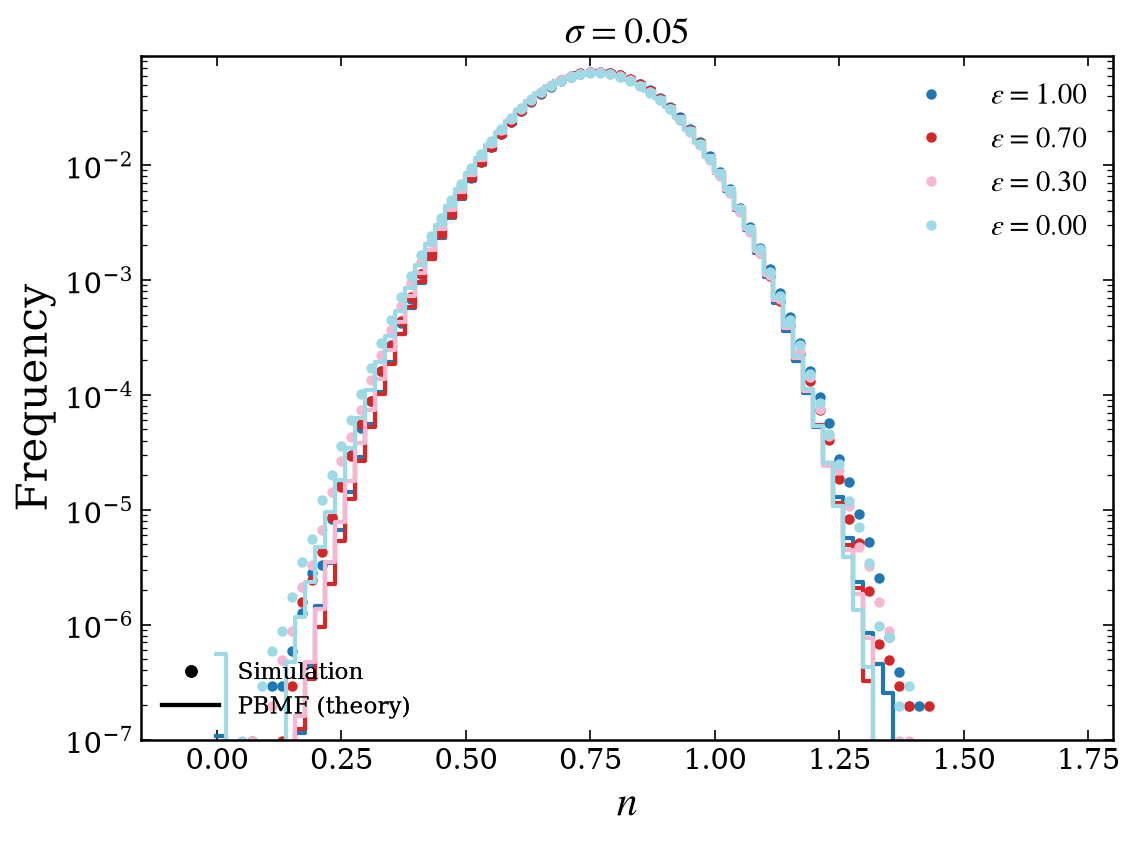

In [147]:
# Fixed sigma, one curve-pair per epsilon
plot_avg_frequency_histogram_vs_eps(sigma=0.05, dn=0.02, eps_values=eps_list, 
                                    ymin=1e-7, ymax=9e-2, xmax=1.8, logscaley=True)

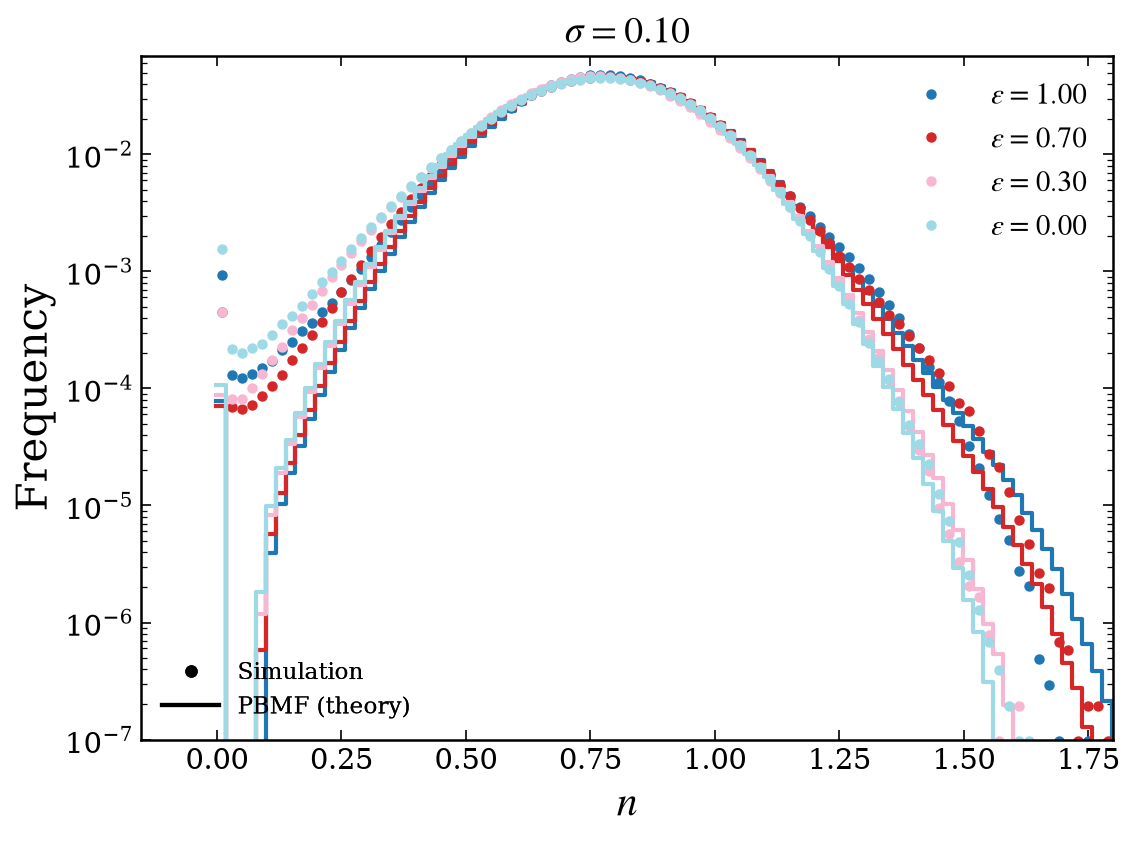

In [148]:
# Fixed sigma, one curve-pair per epsilon
plot_avg_frequency_histogram_vs_eps(sigma=0.10, dn=0.02, eps_values=eps_list, 
                                    ymin=1e-7, ymax=7e-2, xmax=1.8, logscaley=True)

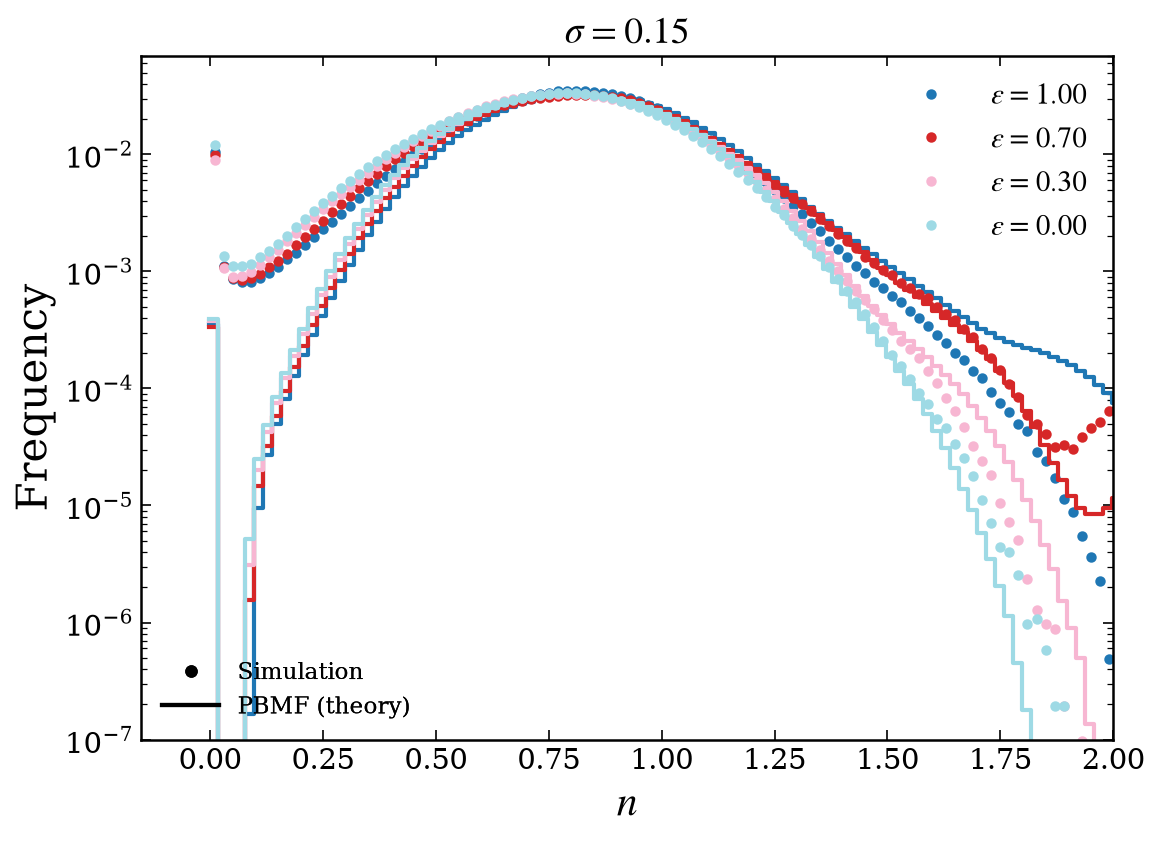

In [149]:
# Fixed sigma, one curve-pair per epsilon
plot_avg_frequency_histogram_vs_eps(sigma=0.15, dn=0.02, eps_values=eps_list, 
                                    ymin=1e-7, ymax=7e-2, xmax=2, logscaley=True)

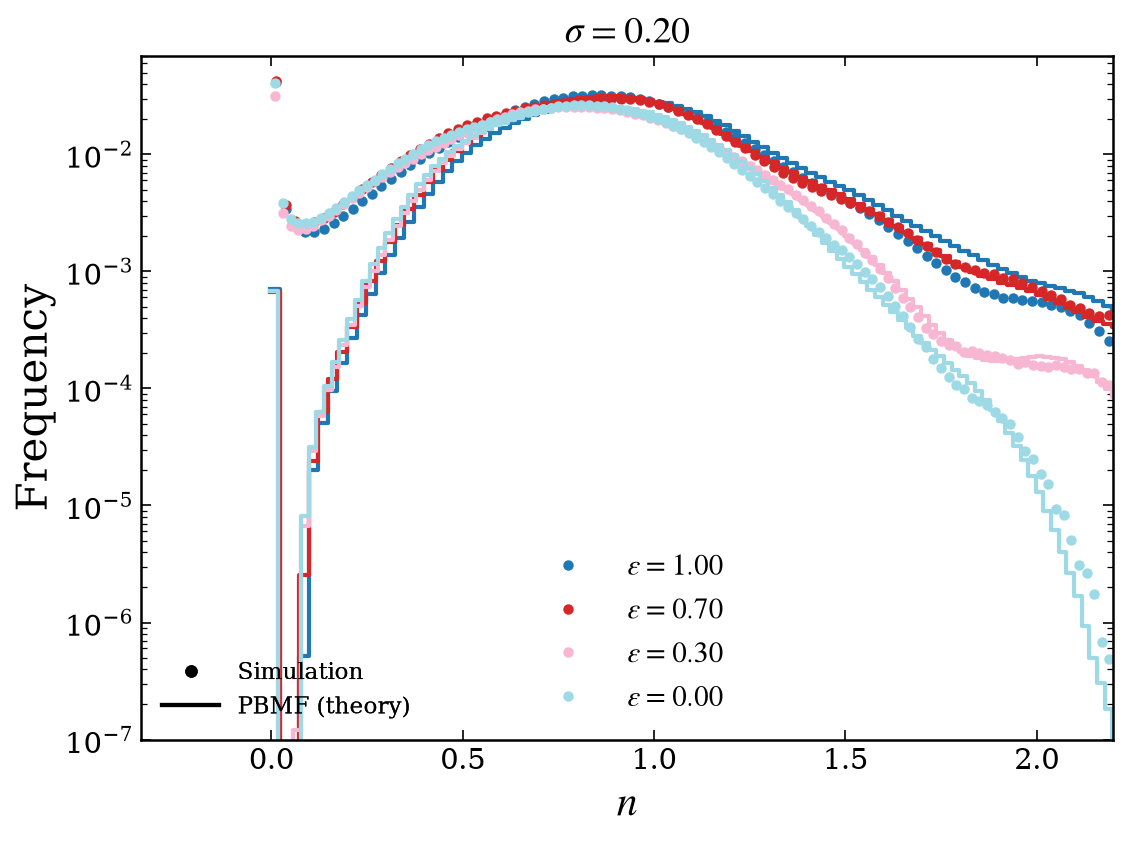

In [150]:
# Fixed sigma, one curve-pair per epsilon
plot_avg_frequency_histogram_vs_eps(sigma=0.20, dn=0.02, eps_values=eps_list, 
                                    ymin=1e-7, ymax=7e-2, xmax=2.2, logscaley=True)

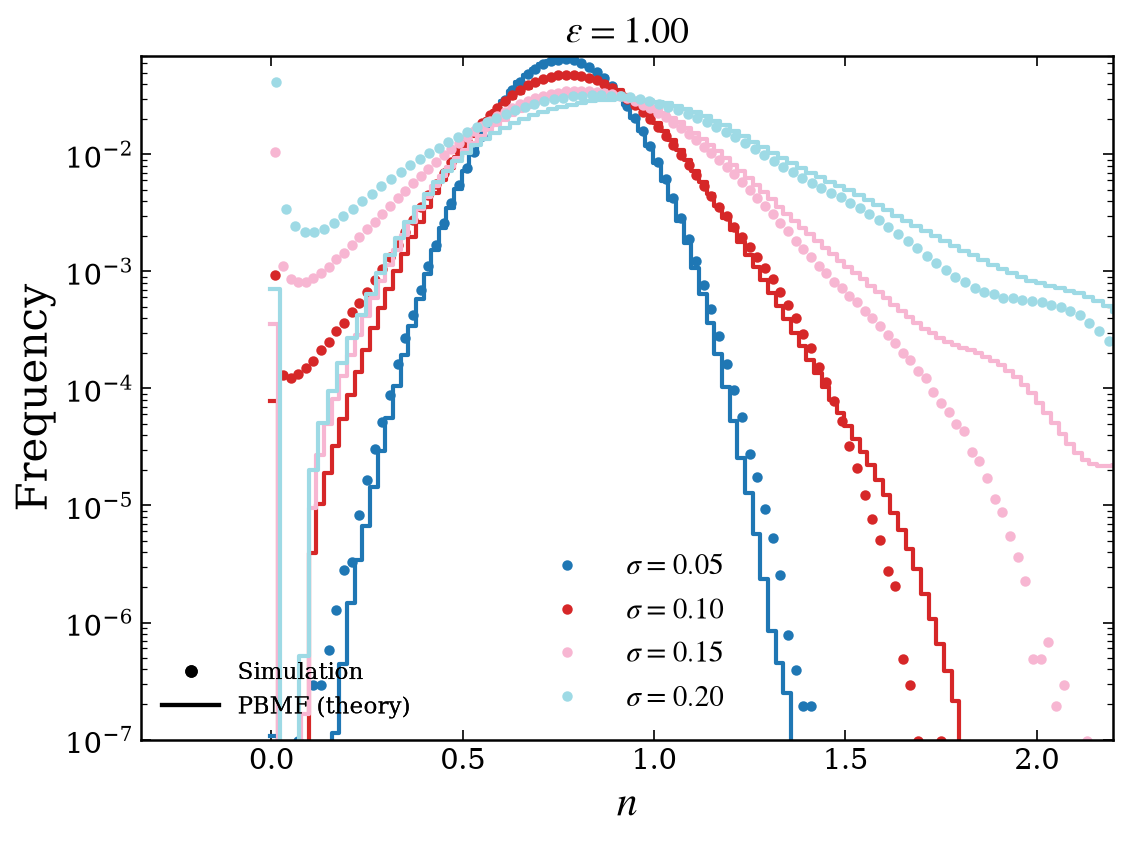

In [151]:
# Fixed epsilon, one curve-pair per sigma
plot_avg_frequency_histogram_vs_sigma(eps=1.0, dn=0.02, logscaley=True, 
                                      ymin=1e-7, ymax=7e-2, xmax=2.2)

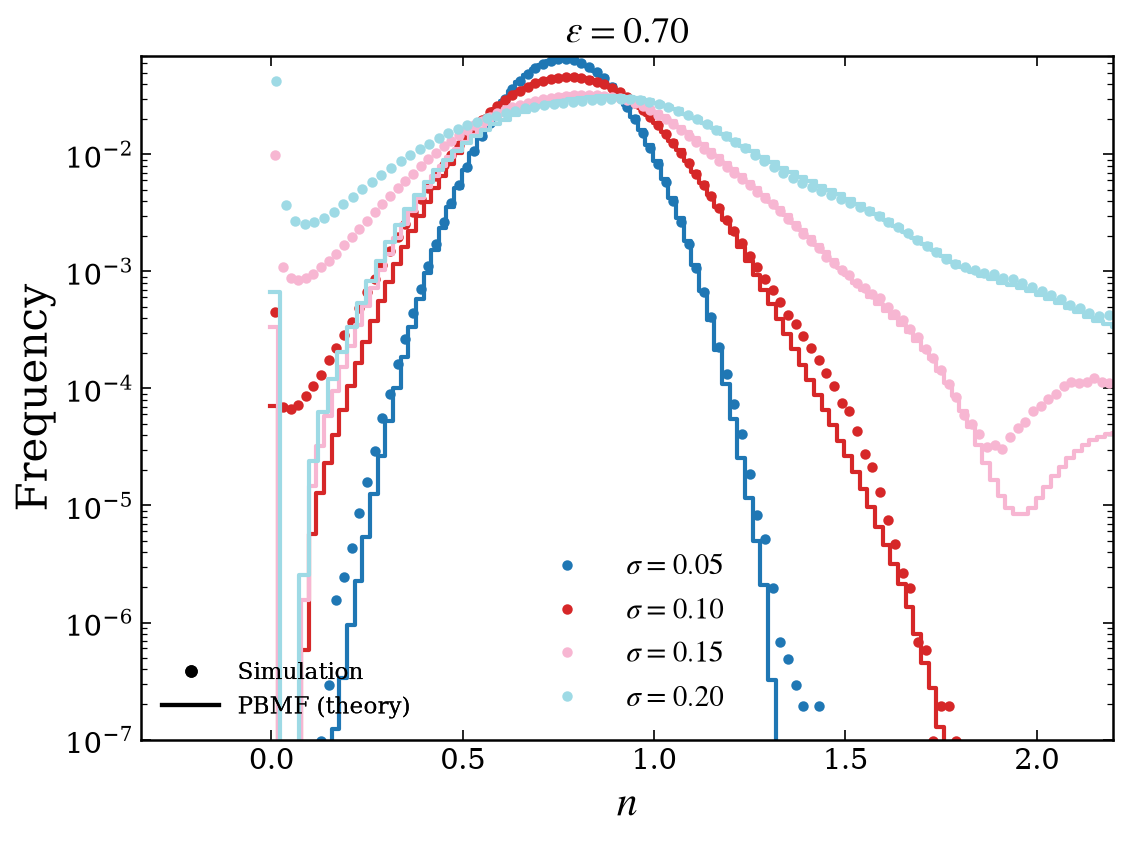

In [155]:
# Fixed epsilon, one curve-pair per sigma
plot_avg_frequency_histogram_vs_sigma(eps=0.7, dn=0.02, logscaley=True, 
                                      ymin=1e-7, ymax=7e-2, xmax=2.2)

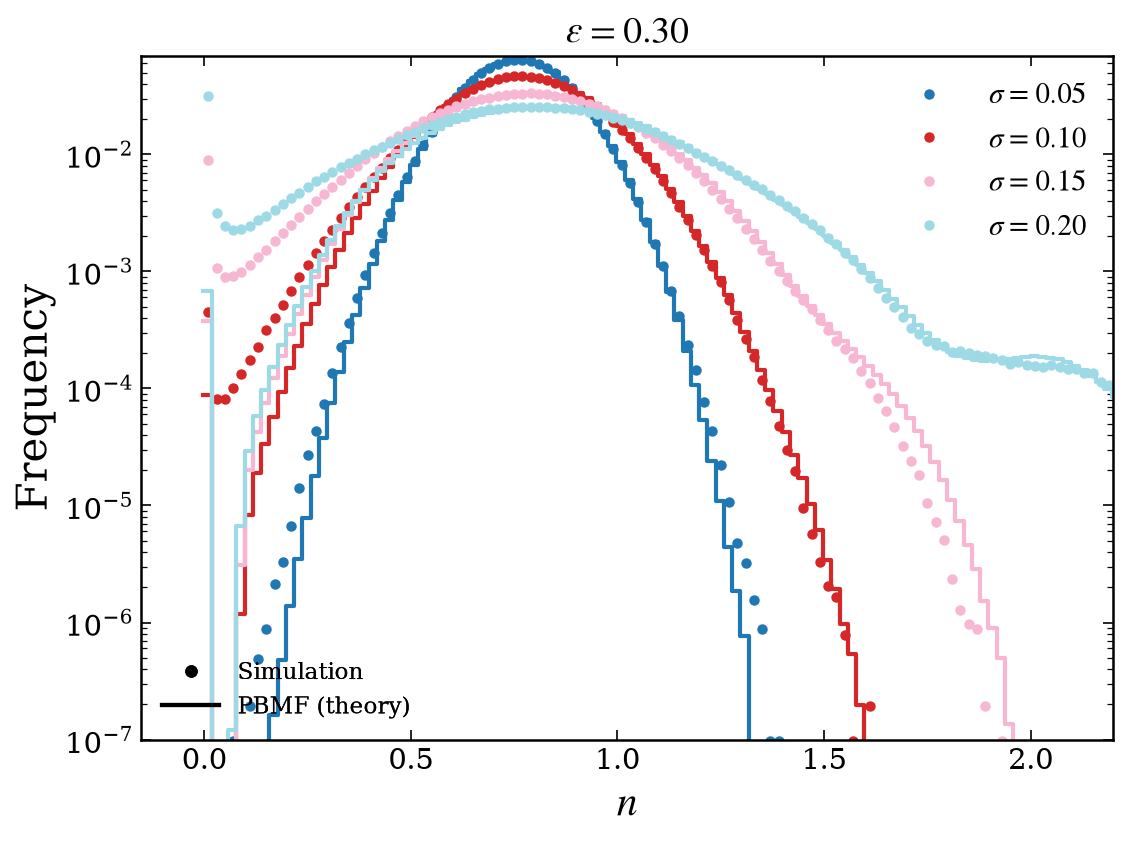

In [156]:
# Fixed epsilon, one curve-pair per sigma
plot_avg_frequency_histogram_vs_sigma(eps=0.3, dn=0.02, logscaley=True, 
                                      ymin=1e-7, ymax=7e-2, xmax=2.2)

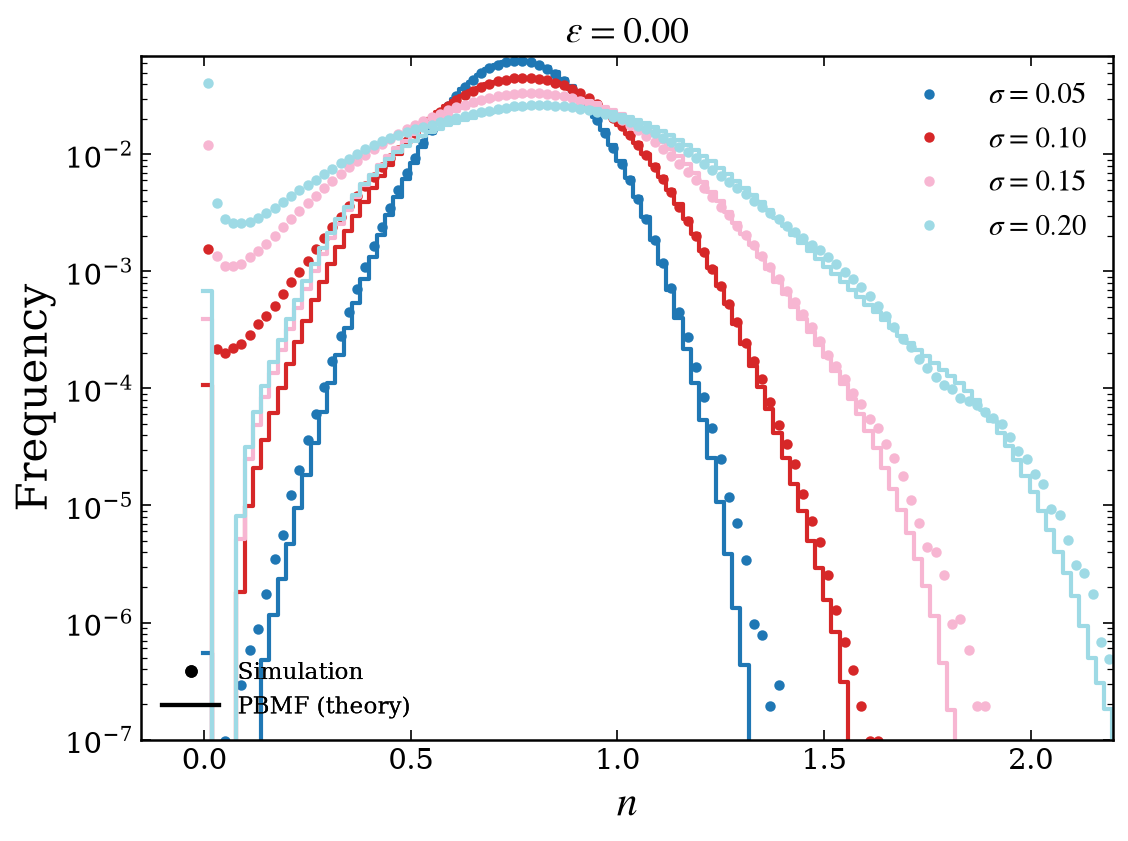

In [157]:
# Fixed epsilon, one curve-pair per sigma
plot_avg_frequency_histogram_vs_sigma(eps=0.0, dn=0.02, logscaley=True, 
                                      ymin=1e-7, ymax=7e-2, xmax=2.2)

## 2. Individual species distributions: the species PBMF flagged as top non-Gaussian

For a given (epsilon, sigma, sgraph), `preprocess_Langevin_distributions.py --pbmf-dir` already pooled every PBMF `*_top_nongaussian_species.txt` replicate *for that sgraph* to find the species PBMF ever flagged as most non-Gaussian, and wrote each such species' own count/frequency/density (from the Langevin data) to one `*_PBMF_top_nongaussian_species.txt` file. This section re-pools the matching raw PBMF per-species curves (mean over whichever seedinit replicates, of that sgraph, happened to flag that particular species) and compares them the same way as section 1.

**Unlike section 1, `sgraph` is required here (not `None`)**: a species index is specific to one interaction graph realization (its neighbors and interaction strengths depend on which graph it is), so "species 5, pooled across sgraph" would silently average unrelated species from different ecosystems together. `seedinit` remains optional: with `sgraph` fixed, `seedinit=None` pools PBMF over every seedinit replicate for that sgraph (as before), while `seedinit=<m>` uses one specific replicate.

Only the raw $P(n)$ distribution is available here (not $\hat{P}(n)$): the companion files only carry count/frequency/density of $P$, since there is no natural "count" for the rescaled $\hat{P}$.

In [ ]:
PBMF_SPECIES_HEADER_RE = re.compile(r"species=(\d+)")


def find_pbmf_top_nongaussian_files(pbmf_dist_dir, eps, sigma, sgraph, seedinit=None, tol=1e-6):
    """Every PBMF PBMF_TOP_NONGAUSSIAN_SUFFIX file matching (eps, sigma, sgraph) -- and, if
    seedinit is given, one specific initial condition; otherwise every seedinit PBMF was run
    with for that sgraph. sgraph is required (not pooled over): species indices are specific to
    one interaction graph realization, not comparable across different graphs."""
    pattern = os.path.join(pbmf_dist_dir, f"PBMF_gr_in_RRG_*{PBMF_TOP_NONGAUSSIAN_SUFFIX}")
    matches = []
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(PBMF_TOP_NONGAUSSIAN_SUFFIX)] + ".txt"
        params = parse_pbmf_filename(reconstructed)
        if params is None:
            continue
        if not (np.isclose(params["eps"], eps, atol=tol) and np.isclose(params["sigma"], sigma, atol=tol)):
            continue
        if params["sgraph"] != sgraph:
            continue
        if seedinit is not None and params["seedinit"] != seedinit:
            continue
        matches.append(path)
    return matches


def load_pbmf_top_nongaussian_curves(pbmf_dist_dir, eps, sigma, sgraph, seedinit=None, tol=1e-6):
    """Return dict: species_num (1-indexed, PBMF's own convention) -> list of (n, freqP, freqPhat)
    curves, one per PBMF replicate file (of this sgraph) whose own top-N list happened to
    include that species (not every replicate selects the same species)."""
    paths = find_pbmf_top_nongaussian_files(pbmf_dist_dir, eps, sigma, sgraph, seedinit=seedinit, tol=tol)
    curves = {}
    for path in paths:
        header_species = []
        column_line = None
        with open(path) as f:
            for line in f:
                if not line.startswith("#"):
                    break
                column_line = line[1:].strip()
                m = PBMF_SPECIES_HEADER_RE.search(line)
                if m:
                    header_species.append(int(m.group(1)))
        if column_line is None or not header_species:
            continue
        columns = column_line.split("\t")
        data = np.loadtxt(path, comments="#")
        n = data[:, 0]
        for sp in header_species:
            try:
                p_idx = columns.index(f"freqP_species{sp}")
                phat_idx = columns.index(f"freqPhat_species{sp}")
            except ValueError:
                continue
            curves.setdefault(sp, []).append((n, data[:, p_idx], data[:, phat_idx]))
    return curves


def pooled_species_curve(curves_list, use_phat=False):
    """Average (over whichever PBMF replicates flagged this species) a species' freqP(n) or
    freqPhat(n) curve, zero-padding shorter (early-truncated) replicate grids up to the
    longest, same convention as load_pbmf_pooled_average."""
    col = 2 if use_phat else 1
    n_ref = max((c[0] for c in curves_list), key=len)
    stacked = np.zeros((len(curves_list), len(n_ref)))
    for i, c in enumerate(curves_list):
        vals = c[col]
        stacked[i, :len(vals)] = vals
    return n_ref, stacked.mean(axis=0), len(curves_list)


def find_langevin_pbmf_top_nongaussian_file(langevin_dist_dir, eps, sigma, sgraph, tol=1e-6):
    """The single Langevin *_PBMF_top_nongaussian_species.txt file matching (eps, sigma,
    sgraph). sgraph is required: this companion file (see preprocess_Langevin_distributions.py
    --pbmf-dir) is written per sgraph, since PBMF's own species selection is scoped to sgraph."""
    pattern = os.path.join(langevin_dist_dir, f"Lotka-Volterra_*{LANGEVIN_PBMF_TOP_NONGAUSSIAN_SUFFIX}")
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(LANGEVIN_PBMF_TOP_NONGAUSSIAN_SUFFIX)] + ".txt"
        params = parse_langevin_filename(reconstructed)
        if params is None:
            continue
        if (np.isclose(params["epsilon"], eps, atol=tol) and np.isclose(params["sigma"], sigma, atol=tol)
                and params["sgraph"] == sgraph):
            return path
    return None


def load_langevin_species_data(path):
    """Return (n, dict: species_idx (0-indexed, Langevin's own convention) -> (count, freq))
    from a Langevin *_PBMF_top_nongaussian_species.txt file."""
    column_line = None
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):
                break
            column_line = line[1:].strip()
    columns = column_line.split("\t")
    data = np.loadtxt(path, comments="#")
    n = data[:, 0]
    species_re = re.compile(r"count_species(\d+)")
    species_indices = sorted(int(m.group(1)) for c in columns for m in [species_re.match(c)] if m)
    per_species = {}
    for idx in species_indices:
        count = data[:, columns.index(f"count_species{idx}")]
        freq = data[:, columns.index(f"freq_species{idx}")]
        per_species[idx] = (count, freq)
    return n, per_species


def list_pbmf_selected_species(eps, sigma, sgraph, langevin_dist_dir=LANGEVIN_DIST_DIR):
    """The (0-indexed) species PBMF flagged as top non-Gaussian for (eps, sigma, sgraph), i.e.
    the species available to plot_species_*_histogram below. sgraph is required (see
    find_langevin_pbmf_top_nongaussian_file)."""
    path = find_langevin_pbmf_top_nongaussian_file(langevin_dist_dir, eps, sigma, sgraph)
    if path is None:
        return []
    _, per_species = load_langevin_species_data(path)
    return sorted(per_species.keys())

In [ ]:
def _plot_species_multi(eps, sigma, sgraph, dn, kind, seedinit=None, species_indices=None,
                         pbmf_dist_dir=PBMF_DIST_DIR, langevin_dist_dir=LANGEVIN_DIST_DIR,
                         n_samples=N_SAMPLES,
                         figsize=(8, 6), dpi=150, legend_loc='best', legend_fontsize=14,
                         title_fontsize=18, label_fontsize=20, tick_fontsize=14,
                         linewidth=2, markersize=4, logscalex=False, logscaley=False, ax=None, save_to=None,
                         xmin=None, xmax=None, ymin=None, ymax=None, title=None):
    """Overlay several species (simulation as small points at bin centers + PBMF theory as a
    solid line, one color per species) in one plot. species_indices are Langevin's 0-indexed
    species numbers (see list_pbmf_selected_species); every PBMF-flagged species for
    (eps, sigma, sgraph) is used if not given.

    sgraph is required (unlike in section 1's _plot_avg_multi): a species index is specific to
    one interaction graph realization, so there is no meaningful way to pool individual-species
    curves across different sgraph. seedinit only affects PBMF (the simulation has no notion of
    seedinit): seedinit=None pools PBMF over every seedinit replicate of this sgraph that
    flagged a given species, while seedinit=<m> restricts to that one replicate.

    Simulation and PBMF are each already a frequency histogram on their own native grid, at a
    matching native bin width, so they're rebinned together (see rebin_histogram_pair) onto a
    common bin width close to dn -- dn (not a bin count) is the physically meaningful quantity
    to request.
    """
    if kind not in ("frequency", "count"):
        raise ValueError("kind must be 'frequency' or 'count'")
    if sgraph is None:
        raise ValueError("sgraph is required for per-species plots: species indices are specific "
                          "to one interaction graph realization and cannot be pooled across sgraph.")

    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })

    langevin_path = find_langevin_pbmf_top_nongaussian_file(langevin_dist_dir, eps, sigma, sgraph)
    if langevin_path is None:
        print(f"  [warn] no Langevin PBMF-top-nongaussian file for eps={eps}, sigma={sigma}, sgraph={sgraph}")
        return
    native_centers, per_species = load_langevin_species_data(langevin_path)

    if species_indices is None:
        species_indices = sorted(per_species.keys())
    if not species_indices:
        print("  [warn] no species to plot")
        return

    pbmf_curves = load_pbmf_top_nongaussian_curves(pbmf_dist_dir, eps, sigma, sgraph, seedinit=seedinit)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.subplots_adjust(left=0.17, bottom=0.14, right=0.98, top=0.90)
    else:
        fig = ax.figure
    color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(species_indices), 1)))

    # dn_seen = set()
    for idx, species_idx in enumerate(species_indices):
        color = color_cycle[idx % len(color_cycle)]
        if species_idx not in per_species:
            print(f"  [warn] species {species_idx} not in {os.path.basename(langevin_path)}")
            continue
        native_count, native_freq = per_species[species_idx]
        native_sim = native_freq if kind == "frequency" else native_count

        species_num = species_idx + 1  # PBMF's own (1-indexed) convention
        if species_num not in pbmf_curves:
            print(f"  [warn] species {species_idx} (PBMF species={species_num}) not flagged by "
                  f"any PBMF replicate for eps={eps}, sigma={sigma}, sgraph={sgraph}"
                  + (f", seedinit={seedinit}" if seedinit is not None else ""))
            continue
        pbmf_n, pbmf_native_freq, _n_replicates = pooled_species_curve(pbmf_curves[species_num])
        pbmf_native = pbmf_native_freq if kind == "frequency" else pbmf_native_freq * n_samples

        new_edges, new_centers, sim_vals, pbmf_edges, pbmf_centers, pbmf_vals, dn_new = rebin_histogram_pair(
            native_centers, native_sim, pbmf_n, pbmf_native, dn
        )
        if dn_new is None:
            continue
        # dn_seen.add(dn_new)

        ax.plot(new_centers, sim_vals, marker="o", linestyle="none", markersize=markersize,
                color=color, label=f"species {species_idx}")
        ax.step(pbmf_edges, np.append(pbmf_vals, pbmf_vals[-1]), where="post",
                linewidth=linewidth, color=color)

    if logscalex:
        ax.set_xscale("log")
    if logscaley:
        ax.set_yscale("log")
    ax.set_xlabel(r"$n$", fontsize=label_fontsize)
    ax.set_ylabel("Frequency" if kind == "frequency" else "Count", fontsize=label_fontsize)
    seedinit_label = f", seedinit={seedinit}" if seedinit is not None else ""
    # dn_label = f"dn={dn_seen.pop():.4g}" if len(dn_seen) == 1 else f"dn={sorted(dn_seen)}"
    # ttl = title if title is not None else fr"$\epsilon={eps:.2f}$, $\sigma={sigma:.2f}$ ({dn_label})"
    ttl = title if title is not None else fr"$\epsilon={eps:.2f}$, $\sigma={sigma:.2f}$, sgraph={sgraph}{seedinit_label}"
    ax.set_title(ttl, fontsize=title_fontsize)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscalex:
        ax.xaxis.set_major_formatter(LogFormatterMathtext())
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

    main_legend = ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5)
    ax.add_artist(main_legend)
    _add_style_legend(ax)

    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)

    if save_to is not None:
        fig.savefig(save_to)
    plt.show()


def plot_species_frequency_histogram(eps, sigma, sgraph, dn, seedinit=None, species_indices=None, **kwargs):
    """Frequency histogram, one curve-pair per species (see _plot_species_multi); every
    PBMF-flagged species for (eps, sigma, sgraph) is shown if species_indices is not given."""
    _plot_species_multi(eps, sigma, sgraph, dn, kind="frequency", seedinit=seedinit,
                         species_indices=species_indices, **kwargs)


def plot_species_count_histogram(eps, sigma, sgraph, dn, seedinit=None, species_indices=None, **kwargs):
    """Like plot_species_frequency_histogram, but on a count scale (frequency * n_samples for
    both sides -- see the N_SAMPLES configuration cell)."""
    _plot_species_multi(eps, sigma, sgraph, dn, kind="count", seedinit=seedinit,
                         species_indices=species_indices, **kwargs)

### Examples

In [ ]:
eps, sigma, sgraph = 1.0, 0.05, 1
species_list = list_pbmf_selected_species(eps, sigma, sgraph)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}, sgraph={sgraph}: {species_list}")
species_plot = species_list[::2]
plot_species_frequency_histogram(eps, sigma, sgraph, dn=0.02, logscaley=True, 
                                 ymin=3e-5, ymax=0.15, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

In [ ]:
eps, sigma, sgraph = 1.0, 0.10, 1
species_list = list_pbmf_selected_species(eps, sigma, sgraph)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}, sgraph={sgraph}: {species_list}")
species_plot = species_list[::2]
plot_species_frequency_histogram(eps, sigma, sgraph, dn=0.02, logscaley=True, 
                                 ymin=3e-5, ymax=0.15, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

In [ ]:
eps, sigma, sgraph = 0.6, 0.10, 1
species_list = list_pbmf_selected_species(eps, sigma, sgraph)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}, sgraph={sgraph}: {species_list}")
species_plot = species_list[::2]
plot_species_frequency_histogram(eps, sigma, sgraph, dn=0.02, logscaley=True, 
                                 ymin=3e-5, ymax=0.15, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

In [ ]:
eps, sigma, sgraph = 0.2, 0.10, 1
species_list = list_pbmf_selected_species(eps, sigma, sgraph)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}, sgraph={sgraph}: {species_list}")
species_plot = species_list[::2]
plot_species_frequency_histogram(eps, sigma, sgraph, dn=0.02, logscaley=True, 
                                 ymin=3e-5, ymax=0.15, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

In [ ]:
eps, sigma, sgraph = 1.0, 0.20, 1
species_list = list_pbmf_selected_species(eps, sigma, sgraph)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}, sgraph={sgraph}: {species_list}")
species_plot = species_list[::2]
plot_species_frequency_histogram(eps, sigma, sgraph, dn=0.02, logscaley=True, 
                                 ymin=3e-5, ymax=0.15, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

In [ ]:
eps, sigma, sgraph = 0.6, 0.20, 1
species_list = list_pbmf_selected_species(eps, sigma, sgraph)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}, sgraph={sgraph}: {species_list}")
species_plot = species_list[::2]
plot_species_frequency_histogram(eps, sigma, sgraph, dn=0.02, logscaley=True, 
                                 ymin=3e-5, ymax=0.15, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

In [ ]:
eps, sigma, sgraph = 0.2, 0.20, 1
species_list = list_pbmf_selected_species(eps, sigma, sgraph)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}, sgraph={sgraph}: {species_list}")
species_plot = species_list[::2]
plot_species_frequency_histogram(eps, sigma, sgraph, dn=0.02, logscaley=True, 
                                 ymin=1e-5, ymax=0.15, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)

In [ ]:
eps, sigma, sgraph = 0.0, 0.20, 1
species_list = list_pbmf_selected_species(eps, sigma, sgraph)
print(f"PBMF-flagged species for eps={eps}, sigma={sigma}, sgraph={sgraph}: {species_list}")
species_plot = species_list[::2]
plot_species_frequency_histogram(eps, sigma, sgraph, dn=0.02, logscaley=True, 
                                 ymin=1e-5, ymax=0.15, xmin=-0.02, xmax=1.2, 
                                 species_indices=species_plot)